# Fitness score prototype (algorithm v0.1)

Reads the raw API pages saved by `audit/run_audit.py` (`audit/output/*.json`) and computes
five subscores plus a total, per local day, each with a confidence value.

**Design rules**
- Every scoring function is pure: DataFrames in, Series out, no I/O. They can be copied
  into `apps/api/app/scoring/` later with no changes.
- Recovery is scored against the person's own 28-day baseline. A score of 70 means "your normal".
- Missing data is explicit. Weights are renormalised over the components that exist, and the
  confidence value says how much of the score is real.
- All thresholds are placeholders to tune against real data, **not against the seed**.
  The seed is random: it has a 100-minute "bowling" workout with 7,000 steps.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("audit/output")
ALGO_VERSION = "0.1.0"

# Used when a record has no zone_offset (all seed data). Real data: records carry an offset.
DEFAULT_UTC_OFFSET_MIN = 0
SEX = "male"  # "male" or "female": only changes the TRIMP constants
MIN_REPORT_CONFIDENCE = 0.5

WEIGHTS = {"recovery": 0.30, "sleep": 0.25, "training": 0.20, "cardio": 0.15, "activity": 0.10}

## 1. Load and normalise

Decisions made here, because the audit showed they matter:
- **Local days.** Offsets are applied when present. Sleep belongs to the day you *wake up*.
- **One source per metric.** The seed has one source per metric, but real data will not.
  For now, the source with the most samples wins. Replace this with a proper rule later.
- **Sleep minutes come from the stages** (light + deep + REM). `sleep_duration_seconds`
  includes awake time, and `is_nap` was wrong on a 7-hour night, so naps are re-derived.

In [2]:
def load_records(name):
    path = DATA_DIR / f"{name}.json"
    if not path.exists():
        return []
    pages = json.loads(path.read_text())
    return [row for page in pages for row in page.get("data", [])]


def parse_offset(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return DEFAULT_UTC_OFFSET_MIN
    sign = -1 if s.startswith("-") else 1
    hh, mm = s.lstrip("+-").split(":")
    return sign * (int(hh) * 60 + int(mm))


def localize(utc_series, offset_series):
    mins = offset_series.map(parse_offset)
    return utc_series.dt.tz_localize(None) + pd.to_timedelta(mins, unit="m")


# Heart-rate samples are not used in v0.1, so heart_rate.json is skipped (80k rows).
TS_FILES = ["resting_heart_rate", "hrv", "steps", "recovery_timeseries", "body_composition"]


def load_timeseries(files=TS_FILES):
    df = pd.DataFrame([r for f in files for r in load_records(f)])
    offsets = df["zone_offset"] if "zone_offset" in df else pd.Series(None, index=df.index, dtype=object)
    df["ts"] = pd.to_datetime(df["timestamp"], utc=True)
    df["day"] = localize(df["ts"], offsets).dt.normalize()
    df["provider"] = df["source"].map(lambda s: (s or {}).get("provider"))
    df["device"] = df["source"].map(lambda s: (s or {}).get("device"))
    return df[["type", "value", "day", "ts", "provider", "device"]]


def load_sleep():
    df = pd.DataFrame(load_records("sleep_sessions"))
    if df.empty:
        return df
    stages = pd.DataFrame(df["stages"].map(lambda x: x or {}).tolist(), index=df.index)
    df = pd.concat([df.drop(columns=["stages", "sleep_stage_intervals"], errors="ignore"), stages], axis=1)
    offsets = df["zone_offset"] if "zone_offset" in df else pd.Series(None, index=df.index, dtype=object)
    df["start_local"] = localize(pd.to_datetime(df["start_time"], utc=True), offsets)
    df["end_local"] = localize(pd.to_datetime(df["end_time"], utc=True), offsets)
    df["sleep_min"] = df[["light_minutes", "deep_minutes", "rem_minutes"]].sum(axis=1)
    df["in_bed_min"] = df["time_in_bed_seconds"].fillna(df["duration_seconds"]) / 60
    df["wake_day"] = df["end_local"].dt.normalize()
    # Own nap rule: short, or starting mid-day. Ignores the provider's is_nap flag.
    df["is_nap_v2"] = (df["sleep_min"] < 180) | df["start_local"].dt.hour.between(9, 17)
    return df


def load_workouts():
    df = pd.DataFrame(load_records("workouts"))
    if df.empty:
        return df
    offsets = df["zone_offset"] if "zone_offset" in df else pd.Series(None, index=df.index, dtype=object)
    df["day"] = localize(pd.to_datetime(df["start_time"], utc=True), offsets).dt.normalize()
    df["dur_min"] = df["duration_seconds"] / 60
    df["avg_hr"] = df["avg_heart_rate_bpm"]
    df["max_hr"] = df["max_heart_rate_bpm"]
    return df


ts, sleep, workouts = load_timeseries(), load_sleep(), load_workouts()
print(len(ts), "time-series rows |", len(sleep), "sleep sessions |", len(workouts), "workouts")
print("Metric types:", sorted(ts["type"].unique()))

35359 time-series rows | 60 sleep sessions | 150 workouts
Metric types: ['body_fat_percentage', 'heart_rate_variability_sdnn', 'oxygen_saturation', 'respiratory_rate', 'resting_heart_rate', 'skin_temperature', 'steps', 'vo2_max', 'weight']


## 2. Building blocks

In [3]:
def daily(ts, metric, how="mean"):
    """One value per local day from the dominant source for this metric."""
    d = ts[ts["type"] == metric]
    if d.empty:
        return pd.Series(dtype=float, name=metric)
    key = d["provider"].fillna("?") + "/" + d["device"].fillna("?")
    d = d[key == key.value_counts().idxmax()]
    return d.groupby("day")["value"].agg(how).astype(float).rename(metric)


def interp(s, xp, fp):
    """Piecewise-linear map, clamped at the ends, NaN stays NaN."""
    out = np.interp(s.to_numpy(dtype=float), xp, fp)
    return pd.Series(out, index=s.index).where(s.notna())


def baseline_z(s, scale_floor, window=28, min_periods=10, smooth=3):
    """Robust z-score of a short smoothed value against the PRIOR 28-day median/MAD."""
    x = s.rolling(smooth, min_periods=2).mean()
    past = s.shift(1)
    med = past.rolling(window, min_periods=min_periods).median()
    mad = past.rolling(window, min_periods=min_periods).apply(
        lambda v: np.nanmedian(np.abs(v - np.nanmedian(v))), raw=True
    )
    scale = (1.4826 * mad).clip(lower=scale_floor)
    return (x - med) / scale


def z_to_score(z, direction):
    """70 = at your baseline. 15 points per robust SD."""
    if direction == "higher":
        s = 70 + 15 * z
    elif direction == "lower":
        s = 70 - 15 * z
    else:  # "center": deviation in either direction is bad
        s = 70 - 15 * z.abs()
    return s.clip(0, 100)


def combine(components, weights):
    """Weighted mean over the components that exist on each day.
    Returns (score, confidence) where confidence = share of weight that was available."""
    df = pd.DataFrame(components)
    w = pd.Series({k: weights[k] for k in df.columns})
    avail = df.notna()
    wsum = (avail * w).sum(axis=1)
    score = (df.fillna(0) * w).sum(axis=1) / wsum.replace(0, np.nan)
    return score, wsum / w.sum()

## 3. Subscores

In [4]:
def recovery_score(ts, cal):
    counts = {m: (ts["type"] == m).sum() for m in ["heart_rate_variability_rmssd", "heart_rate_variability_sdnn"]}
    hrv_metric = max(counts, key=counts.get) if max(counts.values()) > 0 else None  # never mix methods
    specs = {  # name: (metric, direction, min scale, weight)
        "resting_hr": ("resting_heart_rate", "lower", 1.0, 0.35),
        "hrv": (hrv_metric, "higher", 3.0, 0.35),
        "resp_rate": ("respiratory_rate", "center", 0.5, 0.15),
        "skin_temp": ("skin_temperature", "center", 0.15, 0.15),
    }
    comps, w = {}, {}
    for name, (metric, direction, floor, weight) in specs.items():
        if metric is None:
            continue
        s = daily(ts, metric).reindex(cal)
        comps[name] = z_to_score(baseline_z(s, floor), direction)
        w[name] = weight
    return combine(comps, w)


def sleep_score(sleep, cal):
    empty = pd.Series(np.nan, index=cal)
    if sleep.empty:
        return empty, empty * 0
    n = (sleep[~sleep["is_nap_v2"]].sort_values("sleep_min")
         .groupby("wake_day").tail(1).set_index("wake_day").sort_index())
    share = (n["deep_minutes"] + n["rem_minutes"]) / n["sleep_min"]
    eff = n["sleep_min"] / n["in_bed_min"] * 100
    night = (0.5 * interp(n["sleep_min"], [240, 420, 540, 660], [0, 100, 100, 70])
             + 0.3 * interp(share, [0.15, 0.40], [0, 100])
             + 0.2 * interp(eff, [65, 90], [0, 100]))
    mid = n["start_local"] + (n["end_local"] - n["start_local"]) / 2
    mid_min = mid.dt.hour * 60 + mid.dt.minute
    mid_min = mid_min.where(mid_min >= 720, mid_min + 1440)  # unwrap past midnight

    night, mid_min = night.reindex(cal), mid_min.reindex(cal)
    window_mean = night.rolling(7, min_periods=4).mean()        # need >= 4 of the last 7 nights
    regularity = interp(mid_min.rolling(7, min_periods=4).std(), [30, 120], [100, 0])
    score, conf = combine({"nights": window_mean, "regularity": regularity}, {"nights": 0.8, "regularity": 0.2})
    conf = conf * (night.rolling(7, min_periods=1).count() / 7).clip(upper=1)
    return score, conf


def training_score(workouts, ts, cal):
    empty = pd.Series(np.nan, index=cal)
    if workouts.empty:
        return empty, empty * 0
    rhr = daily(ts, "resting_heart_rate").reindex(cal)
    rest = rhr.rolling(28, min_periods=5).median().ffill().bfill().fillna(60)
    w = workouts.dropna(subset=["avg_hr", "dur_min"]).copy()
    hr_max = max(np.nanpercentile(w["max_hr"].dropna(), 99) if w["max_hr"].notna().any() else 190, rest.max() + 30)
    w["rest"] = rest.reindex(w["day"]).to_numpy()
    hrr = ((w["avg_hr"] - w["rest"]) / (hr_max - w["rest"])).clip(0, 1)
    k, b = (0.64, 1.92) if SEX == "male" else (0.86, 1.67)
    w["trimp"] = w["dur_min"] * hrr * k * np.exp(b * hrr)          # Banister TRIMP

    load = w.groupby("day")["trimp"].sum().reindex(cal, fill_value=0.0)
    acute = load.rolling(7, min_periods=7).mean()
    chronic = load.rolling(28, min_periods=14).mean()
    acwr = (acute / chronic).where(chronic >= 3.0)                  # ratio is meaningless on ~zero load
    acwr = acwr.where(pd.Series(cal >= cal[0] + pd.Timedelta(days=14), index=cal))
    load_balance = interp(acwr, [0.3, 0.8, 1.3, 2.0], [0, 100, 100, 0])
    sessions_per_week = (load > 0).astype(float).rolling(28, min_periods=14).mean() * 7
    consistency = interp(sessions_per_week, [0, 3], [0, 100])
    return combine({"load_balance": load_balance, "consistency": consistency},
                   {"load_balance": 0.6, "consistency": 0.4})


def cardio_score(ts, cal):
    # PLACEHOLDER mappings: replace with age/sex norms for VO2 max.
    vo2 = daily(ts, "vo2_max").reindex(cal).ffill(limit=21)
    rhr28 = daily(ts, "resting_heart_rate").reindex(cal).rolling(28, min_periods=10).median()
    return combine({"vo2max": interp(vo2, [25, 55], [0, 100]),
                    "resting_hr_level": interp(rhr28, [45, 80], [100, 0])},
                   {"vo2max": 0.6, "resting_hr_level": 0.4})


def activity_score(ts, cal):
    steps = daily(ts, "steps", "sum").reindex(cal)
    steps7 = steps.rolling(7, min_periods=4).mean()
    return combine({"steps": interp(steps7, [3000, 10000], [0, 100])}, {"steps": 1.0})

## 4. Total score

In [5]:
def compute_scores(ts, sleep, workouts, cal, weights=WEIGHTS):
    parts = {
        "recovery": recovery_score(ts, cal),
        "sleep": sleep_score(sleep, cal),
        "training": training_score(workouts, ts, cal),
        "cardio": cardio_score(ts, cal),
        "activity": activity_score(ts, cal),
    }
    subs = {k: v[0] for k, v in parts.items()}
    confs = {k: v[1] for k, v in parts.items()}
    total, _ = combine(subs, weights)
    w = pd.Series(weights)
    confidence = sum(w[k] * confs[k].fillna(0) for k in w.index) / w.sum()
    out = pd.DataFrame(subs)
    out["total"] = total
    out["confidence"] = confidence
    out["total_reported"] = out["total"].where(out["confidence"] >= MIN_REPORT_CONFIDENCE)
    out["algo_version"] = ALGO_VERSION
    return out


days = pd.concat([ts["day"]] + ([sleep["wake_day"]] if not sleep.empty else [])
                 + ([workouts["day"]] if not workouts.empty else []))
cal = pd.date_range(days.min(), days.max(), freq="D")
scores = compute_scores(ts, sleep, workouts, cal)
scores.dropna(subset=["total"]).tail(10).round(1)

,recovery,sleep,training,cardio,activity,total,confidence,total_reported,algo_version
2024-12-22,70.1,NaN,78.3,72.6,100.0,76.7,0.8,76.7,0.1.0
2024-12-23,69.6,NaN,92.7,73.1,100.0,80.5,0.8,80.5,0.1.0
2024-12-24,72.0,NaN,74.6,51.7,100.0,72.4,0.8,72.4,0.1.0
2024-12-25,69.4,NaN,74.6,51.7,100.0,71.3,0.8,71.3,0.1.0
2024-12-26,69.8,NaN,100.0,54.6,100.0,78.9,0.8,78.9,0.1.0
2024-12-27,67.9,NaN,96.7,59.1,100.0,78.1,0.8,78.1,0.1.0
2024-12-28,67.5,NaN,95.4,59.1,100.0,77.6,0.8,77.6,0.1.0
2024-12-29,64.8,NaN,96.7,54.6,100.0,75.9,0.8,75.9,0.1.0
2024-12-30,62.4,NaN,36.7,54.6,100.0,59.0,0.8,59.0,0.1.0
2024-12-31,61.2,NaN,33.3,54.6,100.0,57.6,0.8,57.6,0.1.0


## 5. Look at it

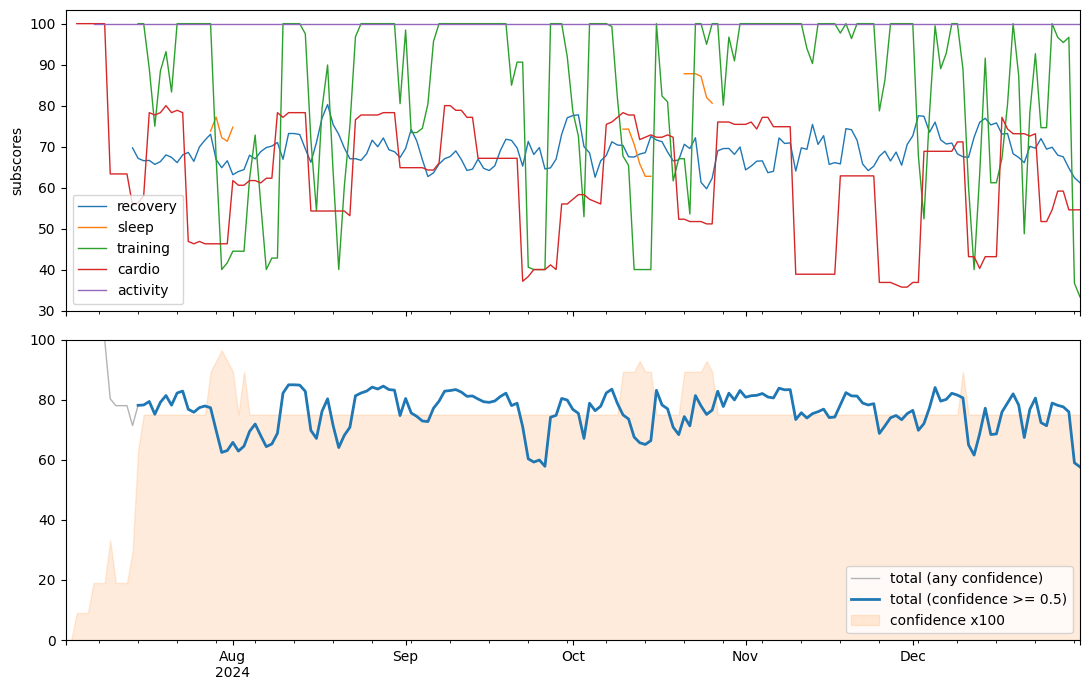

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
scores[["recovery", "sleep", "training", "cardio", "activity"]].plot(ax=axes[0], lw=1)
axes[0].set_ylabel("subscores")
axes[1].plot(scores.index, scores["total"], color="0.7", lw=1, label="total (any confidence)")
axes[1].plot(scores.index, scores["total_reported"], color="C0", lw=2, label=f"total (confidence >= {MIN_REPORT_CONFIDENCE})")
axes[1].fill_between(scores.index, 0, scores["confidence"] * 100, color="C1", alpha=0.15, label="confidence x100")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Checks before trusting any number

**Coverage.** How often does each subscore exist, and what is the typical confidence?

In [9]:
report = pd.DataFrame({
    "days_scored": scores[["recovery", "sleep", "training", "cardio", "activity", "total"]].notna().sum(),
})
report["pct_of_days"] = (report["days_scored"] / len(cal) * 100).round(1)
print(report)
print("\nMean confidence:", round(scores["confidence"].mean(), 2))

          days_scored  pct_of_days
recovery          171         93.4
sleep              20         10.9
training          170         92.9
cardio            181         98.9
activity          178         97.3
total             181         98.9

Mean confidence: 0.72


**Missing-data stress test.** Randomly drop half of the sleep nights. The total should move
only a little, and confidence should visibly fall. If the total jumps, the renormalisation
is hiding too much.

In [10]:
rng = np.random.default_rng(0)
thin = sleep[rng.random(len(sleep)) >= 0.5] if not sleep.empty else sleep
scores_thin = compute_scores(ts, thin, workouts, cal)
cmp = pd.DataFrame({"full": scores["total"], "thin": scores_thin["total"]}).dropna()
print("Abs change in total, half the sleep removed:")
print((cmp["full"] - cmp["thin"]).abs().describe().round(2))
print("\nMean confidence full vs thin:",
      round(scores["confidence"].mean(), 2), "vs", round(scores_thin["confidence"].mean(), 2))

Abs change in total, half the sleep removed:
count    181.00
mean       0.21
std        0.78
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        5.51
dtype: float64

Mean confidence full vs thin: 0.72 vs 0.71


**Sanity check against provider scores.** These are on different scales and from different
providers, so look for direction, not agreement. The field names are unverified, so this
cell prints what it finds instead of assuming.

In [12]:
hs = pd.DataFrame(load_records("health_scores"))
print("Columns:", hs.columns.tolist())
value_col = next((c for c in ["value", "score", "overall_score"] if c in hs.columns), None)
time_col = next((c for c in ["recorded_at", "date", "timestamp"] if c in hs.columns), None)
if value_col and time_col and "category" in hs.columns:
    hs["day"] = pd.to_datetime(hs[time_col], utc=True).dt.tz_localize(None).dt.normalize()
    for cat, col in [("recovery", "recovery"), ("sleep", "sleep")]:
        s = hs[hs["category"] == cat].groupby("day")[value_col].mean()
        joined = pd.concat([s.rename("provider"), scores[col].rename("ours")], axis=1).dropna()
        if len(joined) > 10:
            print(f"{cat}: n={len(joined)}, correlation = {joined.corr().iloc[0, 1]:.2f}")
else:
    print("Could not find score/time columns. Inspect audit/output/health_scores.json and set names above.")

Columns: ['category', 'value', 'qualifier', 'recorded_at', 'zone_offset', 'components', 'id', 'data_source_id', 'provider', 'event_record_id']
recovery: n=165, correlation = -0.16
sleep: n=20, correlation = -0.17


## 7. Next

1. Do not tune weights on this data. Re-run the audit on a real Apple Health export first.
2. Replace placeholder mappings (cardio, activity, sleep targets) with age/sex-based ones.
3. Replace "dominant source wins" with explicit source priority, and test with two overlapping devices.
4. Require real zone offsets. Dates here fall back to UTC.
5. When stable, move the functions in section 3-4 into `apps/api/app/scoring/` and write fixed-input unit tests.